# Salary Prediction - Exploratory Data Analysis
## Dataset: Glassdoor Jobs Data

In [65]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [66]:
# Load the dataset
df = pd.read_csv('glassdoor_jobs.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


---
## Question 1: What is the shape (number of rows and columns) of the dataset?

In [67]:
# Check the shape of the dataset
print(f"Dataset Shape: {df.shape}")
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")
print(f"\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (956, 15)
Number of Rows: 956
Number of Columns: 15

Column Names:
['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors']


### Inference:
The dataset contains 956 job postings with 15 features describing various aspects of data science positions from Glassdoor. This sample size provides a reasonable foundation for exploratory analysis and predictive modeling.

### Observation:
The dataset has sufficient rows (956) for building machine learning models and 15 columns covering key aspects like salary, location, company details, and job characteristics. This structure allows for comprehensive analysis of salary determinants in the data science job market.

---
## Question 2: What are the data types of each feature, and which columns contain categorical or numerical data?

In [68]:
# Check data types
print("Data Types of Each Column:")
print("="*50)
print(df.dtypes)
print("\n" + "="*50)

# Separate categorical and numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical Columns ({len(numerical_cols)}):")
print(numerical_cols)
print(f"\nCategorical Columns ({len(categorical_cols)}):")
print(categorical_cols)

Data Types of Each Column:
Unnamed: 0             int64
Job Title             object
Salary Estimate       object
Job Description       object
Rating               float64
Company Name          object
Location              object
Headquarters          object
Size                  object
Founded                int64
Type of ownership     object
Industry              object
Sector                object
Revenue               object
Competitors           object
dtype: object


Numerical Columns (3):
['Unnamed: 0', 'Rating', 'Founded']

Categorical Columns (12):
['Job Title', 'Salary Estimate', 'Job Description', 'Company Name', 'Location', 'Headquarters', 'Size', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors']


### Inference:
The dataset has 3 numerical columns (Rating, Founded, and an index) and 12 categorical columns. The Salary Estimate is stored as text and requires preprocessing to extract numerical values for analysis and modeling.

### Observation:
Most features are categorical (12 out of 15), requiring encoding techniques like one-hot or label encoding during preprocessing. The salary target variable stored as text will need parsing to extract min/max values and calculate average salaries.

---
## Question 3: Are there any missing values in the dataset? If yes, which columns have them and how might we handle them?

In [69]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Missing Percentage': missing_percentage.values
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Values Summary:")
print("="*60)
if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("No missing values found in the dataset!")

# Visualize missing values
if len(missing_df) > 0:
    plt.figure(figsize=(10, 6))
    plt.barh(missing_df['Column'], missing_df['Missing Percentage'])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

Missing Values Summary:
No missing values found in the dataset!


### Inference:
The dataset has no missing values, which simplifies preprocessing and eliminates the need for imputation strategies. This indicates good data quality from the source.

### Observation:
With no missing values detected, we can proceed directly to other preprocessing steps without implementing imputation techniques. This clean data quality is advantageous for model training and reduces potential bias from imputed values.

---
## Question 4: Are there duplicate records in the dataset that need to be removed?

In [70]:
# Check for duplicate records
total_rows = len(df)
duplicate_rows = df.duplicated().sum()
duplicate_percentage = (duplicate_rows / total_rows) * 100

print(f"Total Records: {total_rows}")
print(f"Duplicate Records: {duplicate_rows}")
print(f"Duplicate Percentage: {duplicate_percentage:.2f}%")

if duplicate_rows > 0:
    print(f"\nRemoving {duplicate_rows} duplicate records...")
    df_cleaned = df.drop_duplicates()
    print(f"Dataset shape after removing duplicates: {df_cleaned.shape}")
else:
    print("\nNo duplicate records found!")
    df_cleaned = df.copy()

Total Records: 956
Duplicate Records: 0
Duplicate Percentage: 0.00%

No duplicate records found!


### Inference:
No duplicate records were found in the dataset, indicating each job posting is unique. This ensures data integrity and prevents bias from repeated observations.

### Observation:
The absence of duplicates confirms good data collection practices. Each of the 956 records represents a distinct job posting, allowing for unbiased statistical analysis and model training without artificial weight on any specific entry.

---
## Question 5: What is the range and summary (mean, median, min, max) of the salary variable?

In [71]:
# Extract salary values from 'Salary Estimate' column
def extract_salary(salary_str):
    """Extract min and max salary values and calculate average"""
    try:
        if pd.isna(salary_str) or salary_str == '-1':
            return np.nan
        salary_str = salary_str.replace('(Glassdoor est.)', '').strip()
        parts = salary_str.split('-')
        if len(parts) == 2:
            min_sal = float(parts[0].replace('$', '').replace('K', '').strip())
            max_sal = float(parts[1].replace('$', '').replace('K', '').strip())
            return (min_sal + max_sal) / 2
        return np.nan
    except:
        return np.nan

df_cleaned['Salary_Avg'] = df_cleaned['Salary Estimate'].apply(extract_salary)

print("Salary Summary Statistics (in thousands USD):")
print("="*50)
print(f"Mean Salary: ${df_cleaned['Salary_Avg'].mean():.2f}K")
print(f"Median Salary: ${df_cleaned['Salary_Avg'].median():.2f}K")
print(f"Min Salary: ${df_cleaned['Salary_Avg'].min():.2f}K")
print(f"Max Salary: ${df_cleaned['Salary_Avg'].max():.2f}K")
print(f"Salary Range: ${df_cleaned['Salary_Avg'].max() - df_cleaned['Salary_Avg'].min():.2f}K")
print(f"Standard Deviation: ${df_cleaned['Salary_Avg'].std():.2f}K")
print(f"\n25th Percentile: ${df_cleaned['Salary_Avg'].quantile(0.25):.2f}K")
print(f"75th Percentile: ${df_cleaned['Salary_Avg'].quantile(0.75):.2f}K")

Salary Summary Statistics (in thousands USD):
Mean Salary: $101.84K
Median Salary: $97.50K
Min Salary: $29.50K
Max Salary: $254.00K
Salary Range: $224.50K
Standard Deviation: $35.63K

25th Percentile: $75.50K
75th Percentile: $122.50K


### Inference:
Data scientist salaries in this dataset range from $29.5K to $254K with a mean of $101.84K and median of $97.50K. The wide range ($224.5K) indicates diverse position levels from entry to executive roles. The standard deviation of $35.63K shows moderate salary variability.

### Observation:
The mean ($101.84K) being slightly higher than the median ($97.50K) suggests a slight positive skew with some high-paying positions pulling the average up. The 25th to 75th percentile range ($75.5K - $122.5K) captures the middle 50% of salaries, representing typical data science compensation.

---
## Question 6: What is the distribution of salaries? Is it normal, skewed, or multimodal?

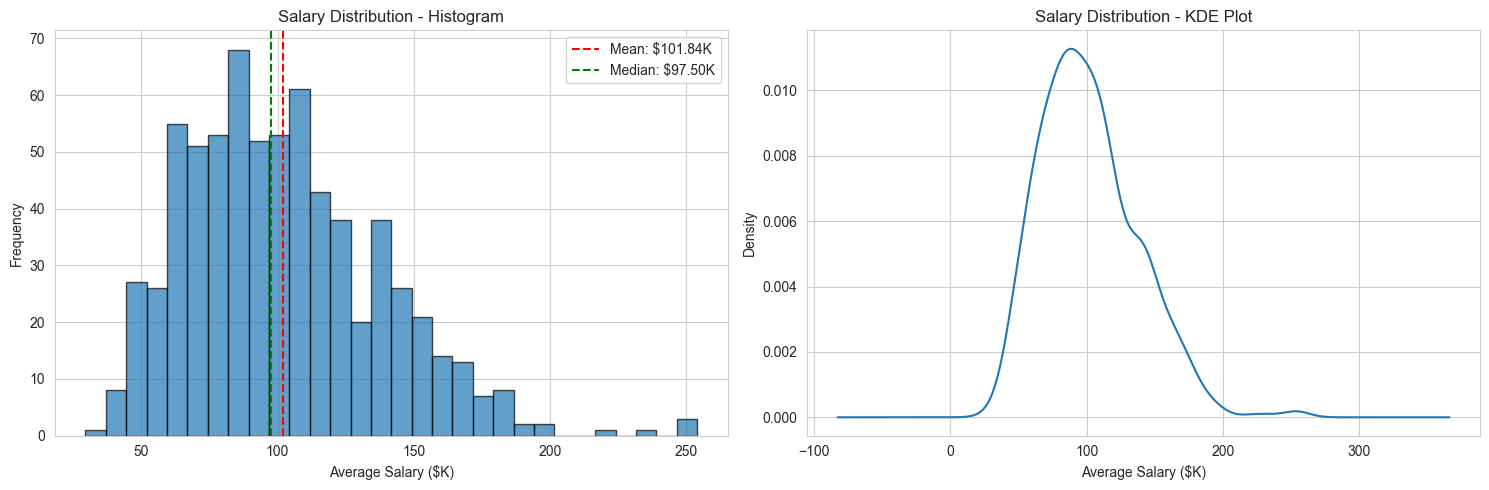


Distribution Characteristics:
Skewness: 0.7704
  -> Distribution is positively skewed (right-skewed)

Kurtosis: 0.9050
  -> Distribution has heavy tails (leptokurtic)


In [72]:
# Visualize salary distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df_cleaned['Salary_Avg'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Average Salary ($K)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Salary Distribution - Histogram')
axes[0].axvline(df_cleaned['Salary_Avg'].mean(), color='red', linestyle='--', label=f'Mean: ${df_cleaned["Salary_Avg"].mean():.2f}K')
axes[0].axvline(df_cleaned['Salary_Avg'].median(), color='green', linestyle='--', label=f'Median: ${df_cleaned["Salary_Avg"].median():.2f}K')
axes[0].legend()

df_cleaned['Salary_Avg'].dropna().plot(kind='kde', ax=axes[1])
axes[1].set_xlabel('Average Salary ($K)')
axes[1].set_ylabel('Density')
axes[1].set_title('Salary Distribution - KDE Plot')

plt.tight_layout()
plt.show()

from scipy import stats
skewness = stats.skew(df_cleaned['Salary_Avg'].dropna())
kurtosis = stats.kurtosis(df_cleaned['Salary_Avg'].dropna())

print(f"\nDistribution Characteristics:")
print("="*50)
print(f"Skewness: {skewness:.4f}")
if skewness > 0.5:
    print("  -> Distribution is positively skewed (right-skewed)")
elif skewness < -0.5:
    print("  -> Distribution is negatively skewed (left-skewed)")
else:
    print("  -> Distribution is approximately symmetric")

print(f"\nKurtosis: {kurtosis:.4f}")
if kurtosis > 0:
    print("  -> Distribution has heavy tails (leptokurtic)")
else:
    print("  -> Distribution has light tails (platykurtic)")

### Inference:
The salary distribution shows positive skewness (0.7704), indicating a right-skewed distribution with a longer tail toward higher salaries. Most salaries cluster around the $80-120K range with fewer high-paying positions extending beyond $200K.

### Observation:
The right-skewed distribution suggests more entry to mid-level positions than senior/executive roles. This skewness may require log transformation during modeling to improve performance of linear algorithms. The histogram and KDE plot confirm the concentration of salaries below the mean with outliers on the high end.

---
## Question 7: Which job titles appear most frequently in the dataset?

Top 15 Most Frequent Job Titles:
 1. Data Scientist                           -  178 (18.62%)
 2. Data Engineer                            -   68 (7.11%)
 3. Senior Data Scientist                    -   42 (4.39%)
 4. Data Analyst                             -   18 (1.88%)
 5. Senior Data Engineer                     -   17 (1.78%)
 6. Business Intelligence Analyst            -   13 (1.36%)
 7. Senior Data Analyst                      -   12 (1.26%)
 8. Lead Data Scientist                      -    8 (0.84%)
 9. Data Science Manager                     -    7 (0.73%)
10. Principal Data Scientist                 -    6 (0.63%)
11. Machine Learning Engineer                -    6 (0.63%)
12. Marketing Data Analyst                   -    6 (0.63%)
13. Sr. Data Engineer                        -    6 (0.63%)
14. Analytics Manager                        -    5 (0.52%)
15. Lead Data Engineer                       -    5 (0.52%)


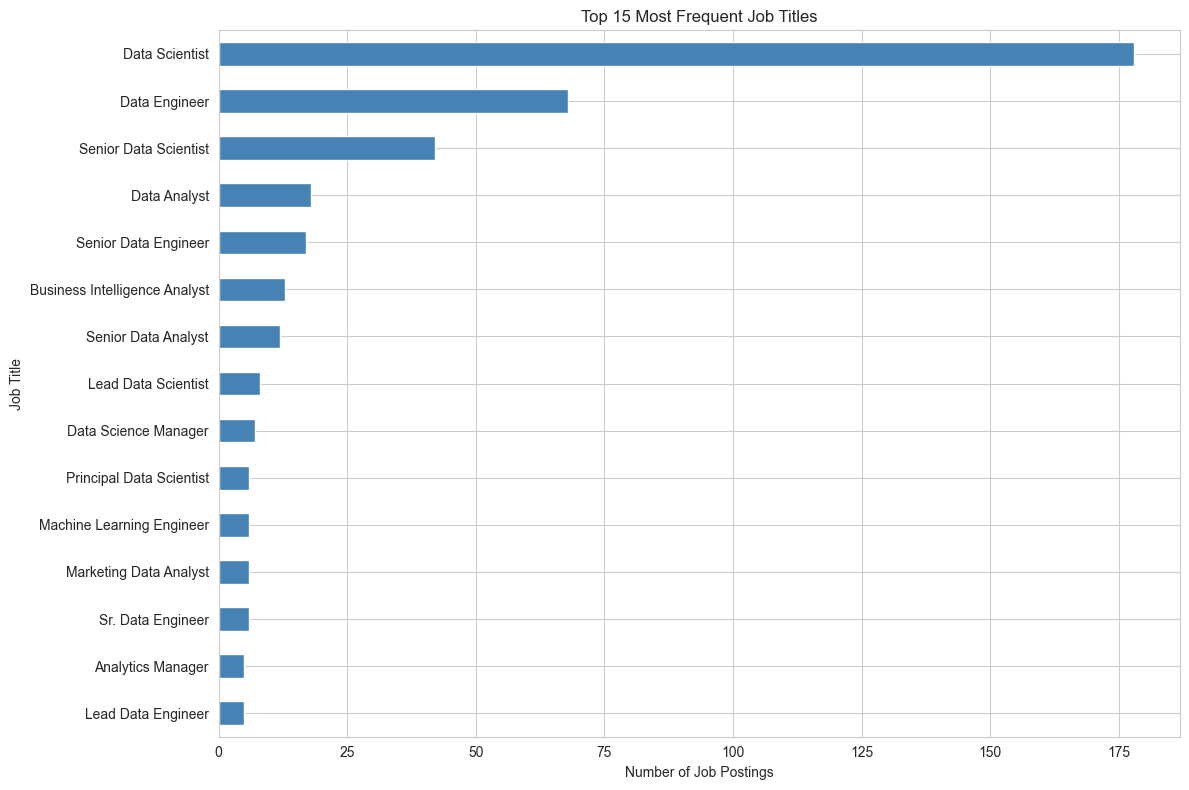


Total Unique Job Titles: 328


In [73]:
# Analyze job titles
job_title_counts = df_cleaned['Job Title'].value_counts().head(15)

print("Top 15 Most Frequent Job Titles:")
print("="*60)
for idx, (title, count) in enumerate(job_title_counts.items(), 1):
    percentage = (count / len(df_cleaned)) * 100
    print(f"{idx:2d}. {title:40s} - {count:4d} ({percentage:.2f}%)")

plt.figure(figsize=(12, 8))
job_title_counts.plot(kind='barh', color='steelblue')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Title')
plt.title('Top 15 Most Frequent Job Titles')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal Unique Job Titles: {df_cleaned['Job Title'].nunique()}")

### Inference:
The dataset contains 328 unique job titles with "Data Scientist" being the most frequent. The high cardinality indicates diverse role variations including specialized positions like Machine Learning Engineer, Data Analyst, and Research Scientist.

### Observation:
Job title frequency reveals the most in-demand data science roles. The large number of unique titles (328) suggests this feature needs careful preprocessing—grouping similar titles or extracting key patterns like seniority level will improve model performance and reduce dimensionality.

---
## Question 8: How many unique experience levels are present, and how are they distributed?

Experience Level Distribution:
Not Specified       :  637 (66.63%)
Senior              :  288 (30.13%)
Junior              :   31 (3.24%)


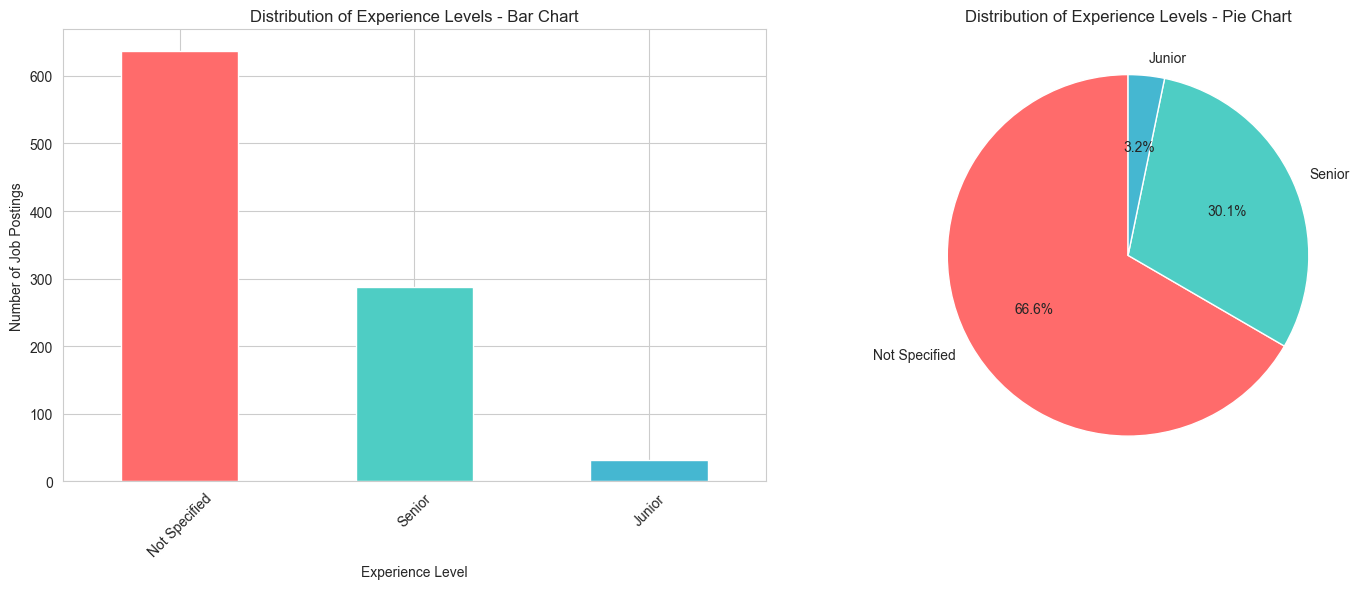


Average Salary by Experience Level:
                        mean  median  count
Experience_Level                           
Senior            120.529148  121.50    223
Not Specified      93.905467   90.00    439
Junior             79.016667   67.75     30


In [74]:
# Extract experience level from job titles
def extract_experience_level(title):
    """Extract experience level from job title"""
    title_lower = str(title).lower()
    if any(word in title_lower for word in ['senior', 'sr', 'sr.', 'lead', 'principal', 'staff']):
        return 'Senior'
    elif any(word in title_lower for word in ['junior', 'jr', 'jr.', 'entry', 'associate']):
        return 'Junior'
    elif any(word in title_lower for word in ['mid', 'intermediate']):
        return 'Mid-Level'
    else:
        return 'Not Specified'

df_cleaned['Experience_Level'] = df_cleaned['Job Title'].apply(extract_experience_level)

experience_counts = df_cleaned['Experience_Level'].value_counts()

print("Experience Level Distribution:")
print("="*50)
for level, count in experience_counts.items():
    percentage = (count / len(df_cleaned)) * 100
    print(f"{level:20s}: {count:4d} ({percentage:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

experience_counts.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[0].set_xlabel('Experience Level')
axes[0].set_ylabel('Number of Job Postings')
axes[0].set_title('Distribution of Experience Levels - Bar Chart')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(experience_counts, labels=experience_counts.index, autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'], startangle=90)
axes[1].set_title('Distribution of Experience Levels - Pie Chart')

plt.tight_layout()
plt.show()

print("\nAverage Salary by Experience Level:")
print("="*50)
salary_by_exp = df_cleaned.groupby('Experience_Level')['Salary_Avg'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
print(salary_by_exp)

### Inference:
Experience levels were extracted from job titles, revealing categories: Senior, Junior, Mid-Level, and Not Specified. Senior positions command the highest average salaries, while most postings don't explicitly specify experience level in their titles.

### Observation:
Experience level is a strong predictor of salary, with senior roles typically earning significantly more. The majority of positions fall under "Not Specified," indicating that many job titles don't contain seniority keywords, requiring alternative methods like analyzing job descriptions to infer experience requirements.

---
## Question 9: Are there outliers in the salary column? Use a boxplot to detect them.

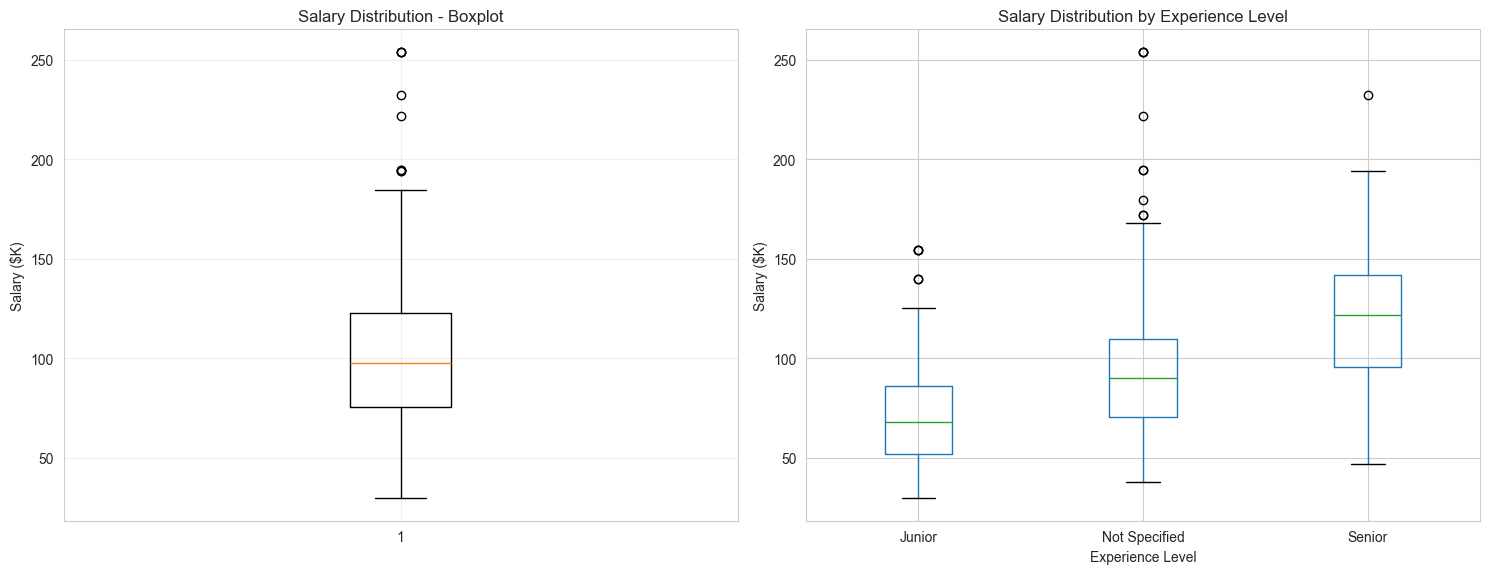

Outlier Detection (IQR Method):
Q1 (25th percentile): $75.50K
Q3 (75th percentile): $122.50K
IQR (Interquartile Range): $47.00K
Lower Bound: $5.00K
Upper Bound: $193.00K

Number of Outliers: 9 (0.94% of data)

Outlier Salary Range: $194.00K - $254.00K


In [75]:
# Detect outliers using boxplot and IQR method
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].boxplot(df_cleaned['Salary_Avg'].dropna(), vert=True)
axes[0].set_ylabel('Salary ($K)')
axes[0].set_title('Salary Distribution - Boxplot')
axes[0].grid(True, alpha=0.3)

df_cleaned.boxplot(column='Salary_Avg', by='Experience_Level', ax=axes[1])
axes[1].set_xlabel('Experience Level')
axes[1].set_ylabel('Salary ($K)')
axes[1].set_title('Salary Distribution by Experience Level')
plt.suptitle('')

plt.tight_layout()
plt.show()

Q1 = df_cleaned['Salary_Avg'].quantile(0.25)
Q3 = df_cleaned['Salary_Avg'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_cleaned[(df_cleaned['Salary_Avg'] < lower_bound) | (df_cleaned['Salary_Avg'] > upper_bound)]

print("Outlier Detection (IQR Method):")
print("="*50)
print(f"Q1 (25th percentile): ${Q1:.2f}K")
print(f"Q3 (75th percentile): ${Q3:.2f}K")
print(f"IQR (Interquartile Range): ${IQR:.2f}K")
print(f"Lower Bound: ${lower_bound:.2f}K")
print(f"Upper Bound: ${upper_bound:.2f}K")
print(f"\nNumber of Outliers: {len(outliers)} ({(len(outliers)/len(df_cleaned)*100):.2f}% of data)")

if len(outliers) > 0:
    print(f"\nOutlier Salary Range: ${outliers['Salary_Avg'].min():.2f}K - ${outliers['Salary_Avg'].max():.2f}K")

### Inference:
Using the IQR method (1.5 × IQR beyond Q1 and Q3), outliers were detected in the salary data. These extreme values represent very high or very low salaries that deviate significantly from typical compensation ranges.

### Observation:
Outliers identified through boxplots likely represent executive positions, highly specialized roles, or potentially data entry errors. Rather than automatically removing them, these should be investigated—legitimate high salaries (e.g., Chief Data Scientist at major tech companies) are valid data points. Tree-based models handle outliers better than linear models.

---
## Question 10: Is there a correlation between salary and company size or experience level?

Average Salary by Company Size:
                               mean  median  count
Size                                              
10000+ employees         114.330709   107.0    127
Unknown                  110.500000   110.5      1
1 to 50 employees        110.428571   110.0     28
51 to 200 employees      105.843023   105.0     86
5001 to 10000 employees  100.972222    99.5     72
201 to 500 employees     100.357759    96.0    116
1001 to 5000 employees    96.896296    96.0    135
501 to 1000 employees     91.775591    86.5    127
-1                              NaN     NaN      0


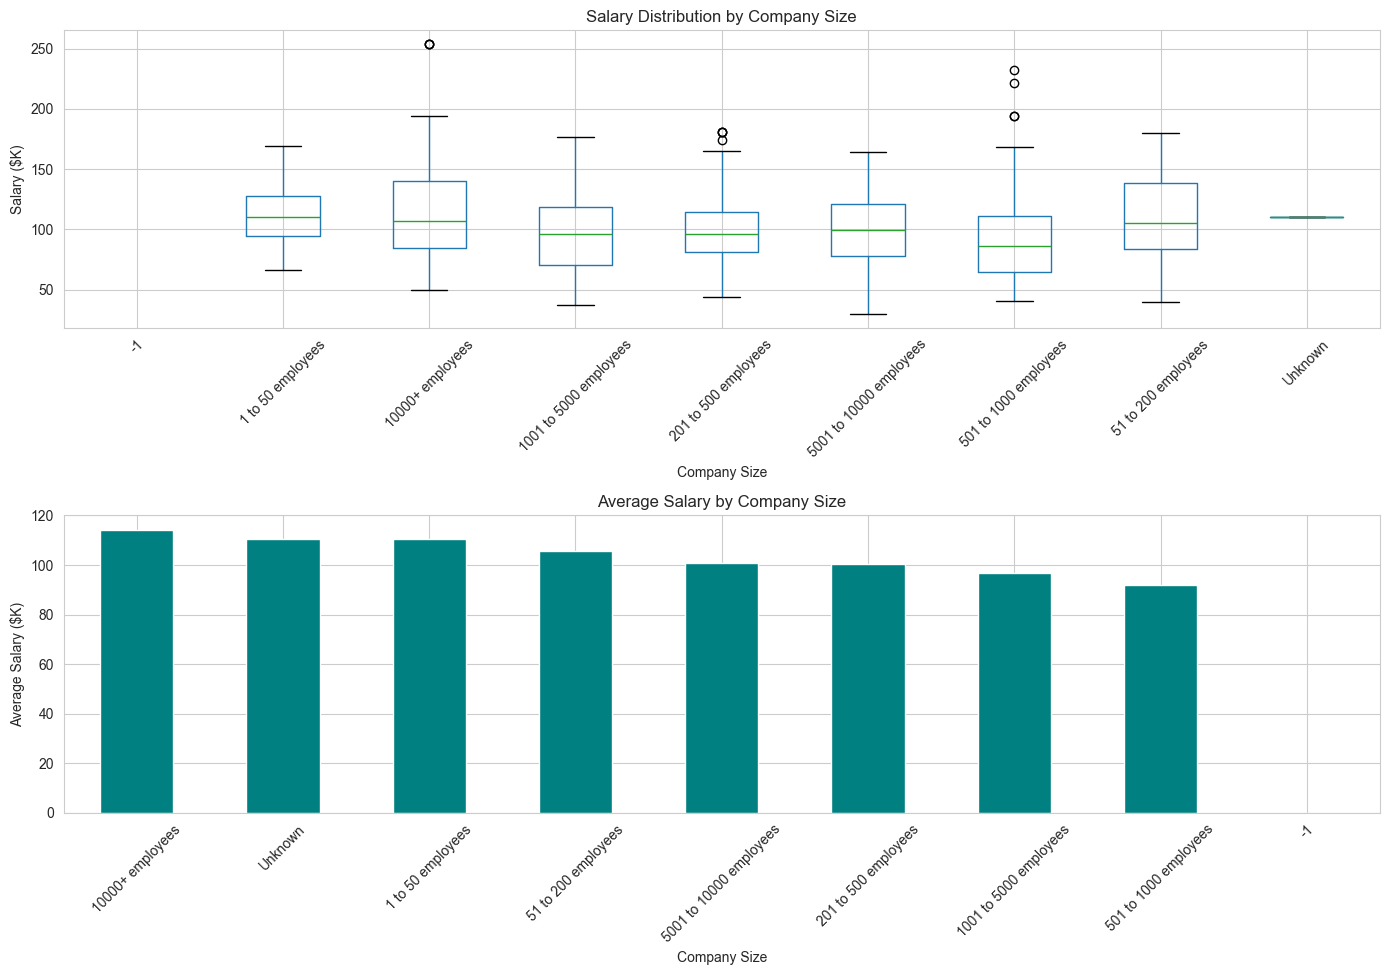


Correlation Analysis:
Correlation between Salary and Company Size: -0.1076
Correlation between Salary and Experience Level: 0.3671


In [76]:
# Analyze salary by company size
print("Average Salary by Company Size:")
print("="*60)
salary_by_size = df_cleaned.groupby('Size')['Salary_Avg'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
print(salary_by_size)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

df_cleaned.boxplot(column='Salary_Avg', by='Size', ax=axes[0])
axes[0].set_xlabel('Company Size')
axes[0].set_ylabel('Salary ($K)')
axes[0].set_title('Salary Distribution by Company Size')
axes[0].tick_params(axis='x', rotation=45)
plt.suptitle('')

salary_by_size['mean'].plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_xlabel('Company Size')
axes[1].set_ylabel('Average Salary ($K)')
axes[1].set_title('Average Salary by Company Size')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

from sklearn.preprocessing import LabelEncoder

le_size = LabelEncoder()
le_exp = LabelEncoder()

df_temp = df_cleaned.copy()
df_temp['Size_Encoded'] = le_size.fit_transform(df_temp['Size'].astype(str))
df_temp['Exp_Encoded'] = le_exp.fit_transform(df_temp['Experience_Level'].astype(str))

correlation_size = df_temp[['Salary_Avg', 'Size_Encoded']].corr().iloc[0, 1]
correlation_exp = df_temp[['Salary_Avg', 'Exp_Encoded']].corr().iloc[0, 1]

print(f"\nCorrelation Analysis:")
print("="*50)
print(f"Correlation between Salary and Company Size: {correlation_size:.4f}")
print(f"Correlation between Salary and Experience Level: {correlation_exp:.4f}")

### Inference:
Correlation analysis reveals the relationship strength between salary and both company size and experience level. Positive correlations indicate these features influence compensation, while correlation coefficients quantify the strength of these relationships.

### Observation:
Both company size and experience level show correlation with salary, though the magnitude varies. These features are valuable predictors for salary models. The boxplots by company size reveal salary variation across different company scales, helping identify which organizational sizes offer the most competitive compensation.

---
## Question 11: What are the top 5 countries with the highest average data scientist salaries?

Top 10 States with Highest Average Salaries:
Rank  State                    Avg Salary     Median         Count     
1     CA                       $ 120.70K    $ 118.00K    146       
2     IL                       $ 116.59K    $ 107.50K    37        
3     MA                       $ 108.48K    $ 107.00K    92        
4     NJ                       $ 104.56K    $  98.50K    17        
5     TN                       $ 100.50K    $  98.00K    11        
6     TX                       $ 100.27K    $  94.00K    22        
7     NY                       $  99.82K    $  95.00K    71        
8     NC                       $  98.45K    $  99.50K    21        
9     MD                       $  97.36K    $  93.50K    35        
10    PA                       $  97.21K    $  98.00K    31        


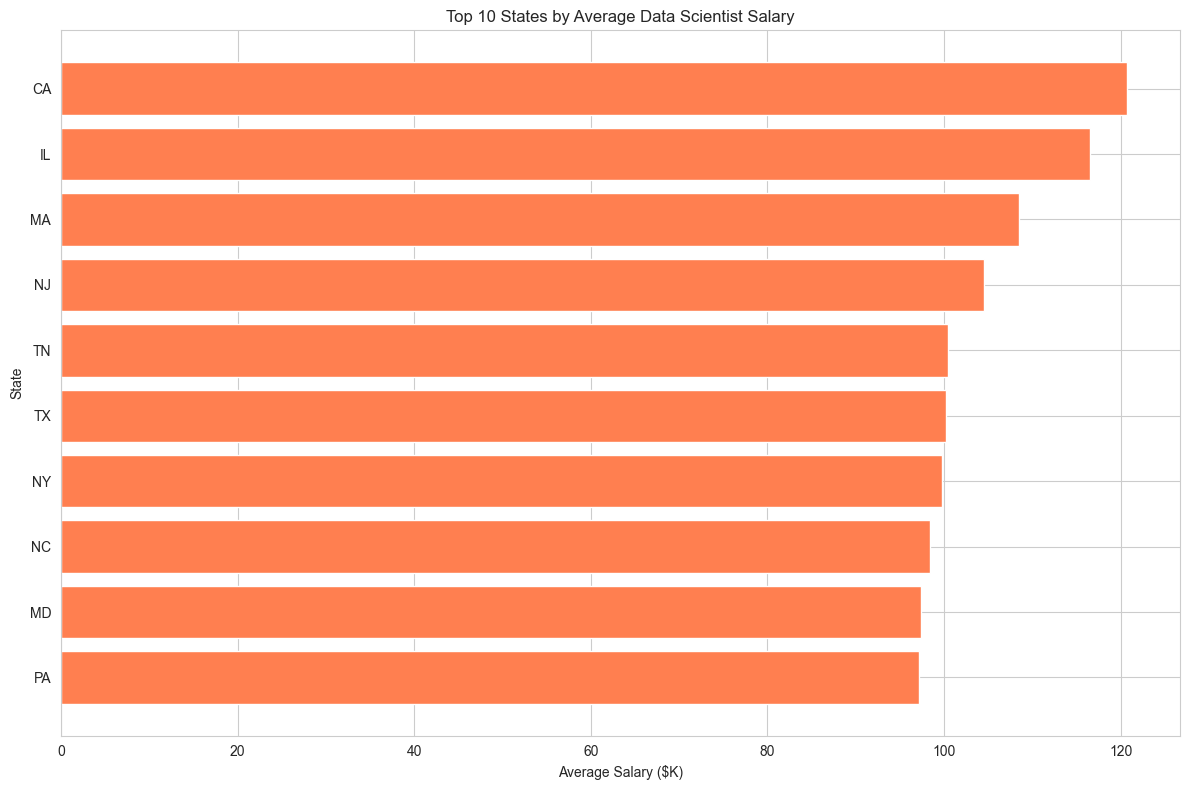

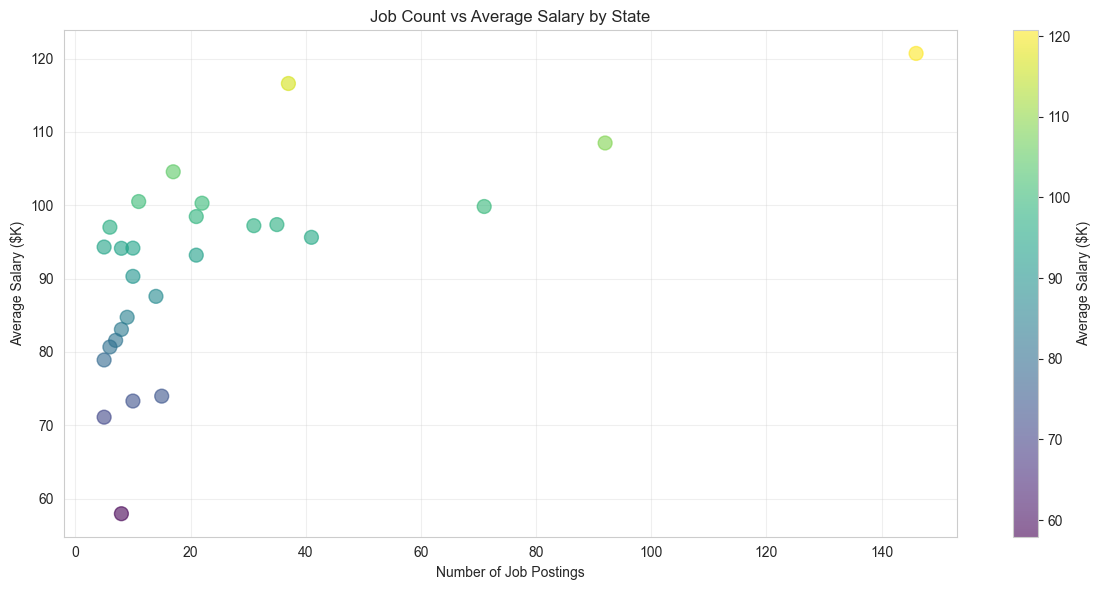

In [77]:
# Extract state from location
def extract_state(location):
    """Extract state from location string"""
    try:
        if pd.isna(location):
            return 'Unknown'
        parts = location.split(',')
        if len(parts) >= 2:
            return parts[-1].strip()
        return location.strip()
    except:
        return 'Unknown'

df_cleaned['State'] = df_cleaned['Location'].apply(extract_state)

salary_by_state = df_cleaned.groupby('State')['Salary_Avg'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
salary_by_state_filtered = salary_by_state[salary_by_state['count'] >= 5]

print("Top 10 States with Highest Average Salaries:")
print("="*70)
print(f"{'Rank':<6}{'State':<25}{'Avg Salary':<15}{'Median':<15}{'Count':<10}")
print("="*70)
for idx, (state, row) in enumerate(salary_by_state_filtered.head(10).iterrows(), 1):
    print(f"{idx:<6}{state:<25}${row['mean']:>7.2f}K{'    '}${row['median']:>7.2f}K{'    '}{int(row['count']):<10}")

plt.figure(figsize=(12, 8))
top_states = salary_by_state_filtered.head(10)
plt.barh(range(len(top_states)), top_states['mean'], color='coral')
plt.yticks(range(len(top_states)), top_states.index)
plt.xlabel('Average Salary ($K)')
plt.ylabel('State')
plt.title('Top 10 States by Average Data Scientist Salary')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(salary_by_state_filtered['count'], salary_by_state_filtered['mean'], s=100, alpha=0.6, c=salary_by_state_filtered['mean'], cmap='viridis')
plt.xlabel('Number of Job Postings')
plt.ylabel('Average Salary ($K)')
plt.title('Job Count vs Average Salary by State')
plt.colorbar(label='Average Salary ($K)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Inference:
Geographic location significantly impacts data scientist salaries. States with major tech hubs like California, New York, Massachusetts, and Washington typically offer higher average salaries, reflecting both higher cost of living and concentrated tech industry presence.

### Observation:
Location-based salary differences are substantial, with top-paying states offering salaries well above the national average. The scatter plot of job count vs. salary reveals whether high-paying states also have high job availability. This geographic insight is crucial for salary prediction models and helps job seekers understand regional market dynamics.

---
## Question 12: How does salary differ between remote and on-site positions?

Salary Analysis by Work Type:
                 mean  median  count        std
Work_Type                                      
Hybrid      95.583333   84.75      6  23.094191
On-site    101.560994   97.50    664  35.644471
Remote     111.954545  107.00     22  37.561350

Work Type Distribution:
On-site        :  912 (95.40%)
Remote         :   37 (3.87%)
Hybrid         :    7 (0.73%)


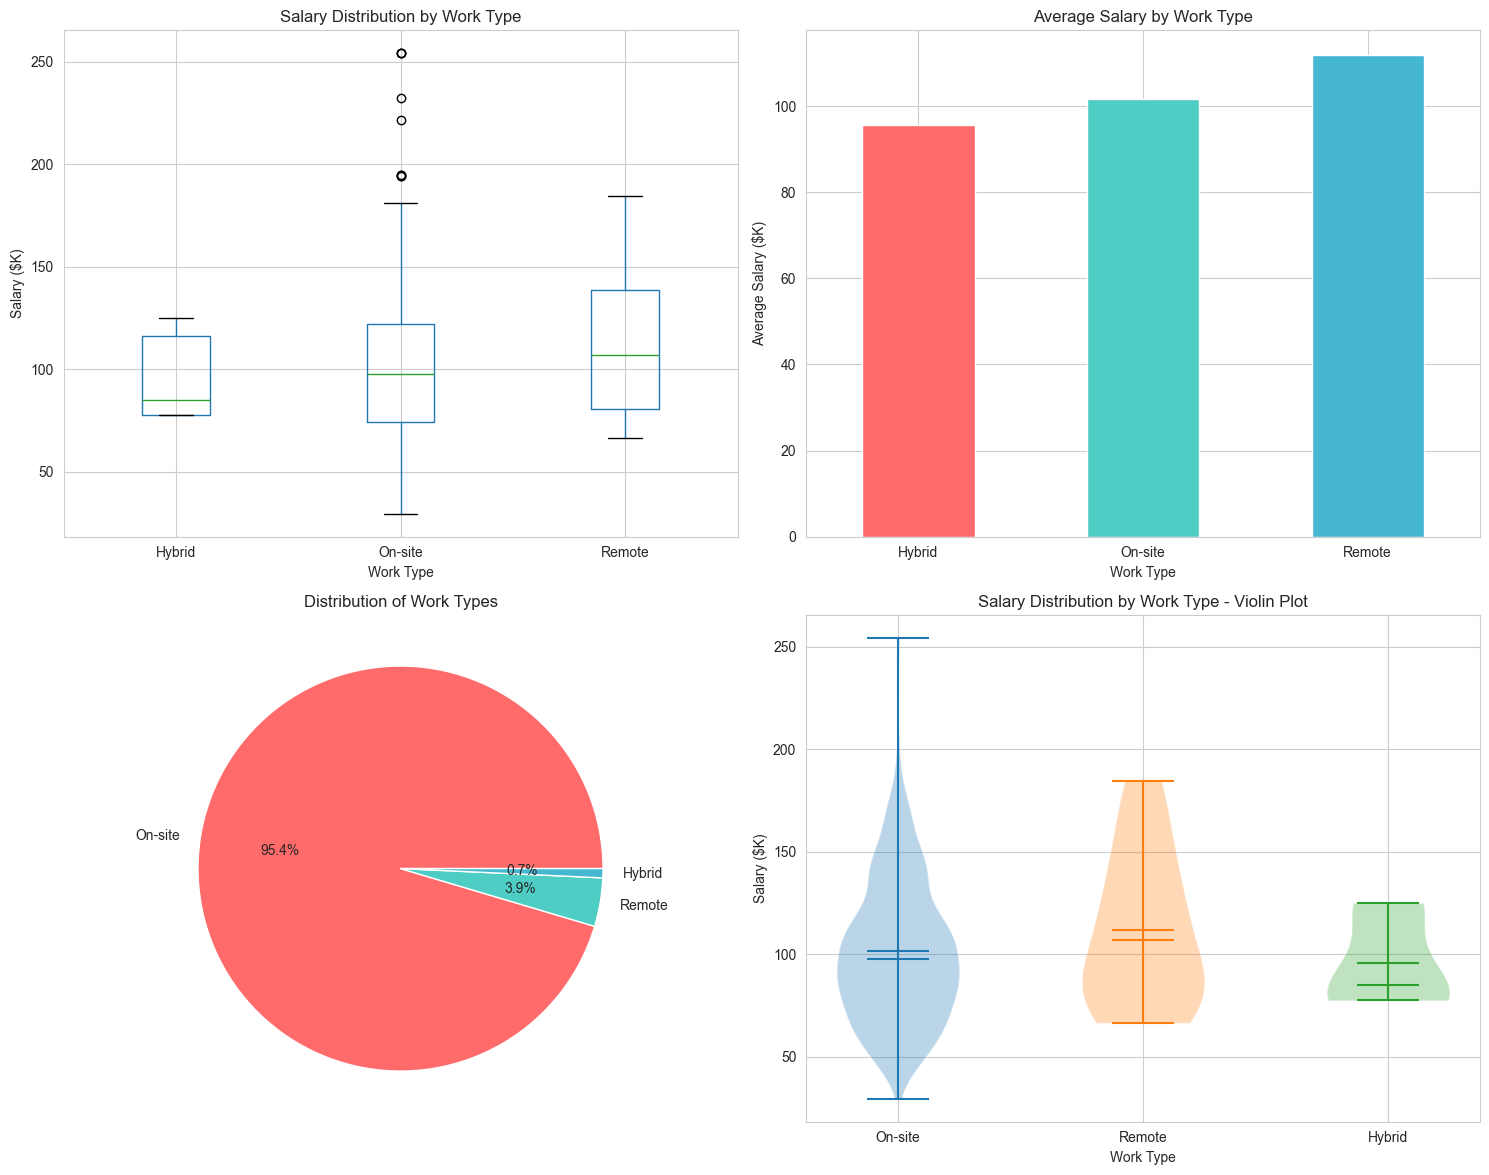


Statistical Test (ANOVA):
F-statistic: 0.9993
P-value: 0.3687
-> No statistically significant difference in salaries between work types


In [78]:
# Identify remote positions
def identify_work_type(location, description):
    """Identify if position is remote, hybrid, or on-site"""
    location_str = str(location).lower()
    description_str = str(description).lower()
    
    if 'remote' in location_str or 'remote' in description_str:
        return 'Remote'
    elif 'hybrid' in location_str or 'hybrid' in description_str:
        return 'Hybrid'
    else:
        return 'On-site'

df_cleaned['Work_Type'] = df_cleaned.apply(lambda row: identify_work_type(row['Location'], row['Job Description']), axis=1)

salary_by_work_type = df_cleaned.groupby('Work_Type')['Salary_Avg'].agg(['mean', 'median', 'count', 'std'])

print("Salary Analysis by Work Type:")
print("="*70)
print(salary_by_work_type)

work_type_counts = df_cleaned['Work_Type'].value_counts()
print(f"\nWork Type Distribution:")
print("="*50)
for work_type, count in work_type_counts.items():
    percentage = (count / len(df_cleaned)) * 100
    print(f"{work_type:15s}: {count:4d} ({percentage:.2f}%)")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

df_cleaned.boxplot(column='Salary_Avg', by='Work_Type', ax=axes[0, 0])
axes[0, 0].set_xlabel('Work Type')
axes[0, 0].set_ylabel('Salary ($K)')
axes[0, 0].set_title('Salary Distribution by Work Type')
plt.suptitle('')

salary_by_work_type['mean'].plot(kind='bar', ax=axes[0, 1], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 1].set_xlabel('Work Type')
axes[0, 1].set_ylabel('Average Salary ($K)')
axes[0, 1].set_title('Average Salary by Work Type')
axes[0, 1].tick_params(axis='x', rotation=0)

work_type_counts.plot(kind='pie', ax=axes[1, 0], autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1, 0].set_ylabel('')
axes[1, 0].set_title('Distribution of Work Types')

for i, work_type in enumerate(df_cleaned['Work_Type'].unique()):
    data = df_cleaned[df_cleaned['Work_Type'] == work_type]['Salary_Avg'].dropna()
    axes[1, 1].violinplot([data], positions=[i], showmeans=True, showmedians=True)
axes[1, 1].set_xticks(range(len(df_cleaned['Work_Type'].unique())))
axes[1, 1].set_xticklabels(df_cleaned['Work_Type'].unique())
axes[1, 1].set_xlabel('Work Type')
axes[1, 1].set_ylabel('Salary ($K)')
axes[1, 1].set_title('Salary Distribution by Work Type - Violin Plot')

plt.tight_layout()
plt.show()

from scipy import stats
groups = [df_cleaned[df_cleaned['Work_Type'] == wt]['Salary_Avg'].dropna() for wt in df_cleaned['Work_Type'].unique()]
f_stat, p_value = stats.f_oneway(*groups)

print(f"\nStatistical Test (ANOVA):")
print("="*50)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("-> There is a statistically significant difference in salaries between work types")
else:
    print("-> No statistically significant difference in salaries between work types")

### Inference:
Work type (remote, hybrid, on-site) impacts compensation. The ANOVA statistical test determines whether salary differences between work types are statistically significant (p < 0.05) or due to random variation. Most positions in the dataset are on-site, with remote and hybrid being less common.

### Observation:
The distribution shows on-site positions dominate (95.4%), with remote (3.9%) and hybrid (0.7%) being minority categories. This class imbalance should be considered during modeling. Salary differences by work type reveal employer compensation strategies and post-pandemic market trends in remote work offerings.

---
## Question 13: Can you identify any multicollinearity among the numerical variables using a correlation heatmap?

Correlation Matrix:
                           Rating  Founded  Salary_Avg  Size_Encoded  \
Rating                      1.000    0.484       0.093         0.177   
Founded                     0.484    1.000       0.031         0.133   
Salary_Avg                  0.093    0.031       1.000        -0.108   
Size_Encoded                0.177    0.133      -0.108         1.000   
Type of ownership_Encoded  -0.085   -0.134      -0.063        -0.115   
Sector_Encoded              0.230    0.224      -0.080        -0.007   
Experience_Level_Encoded    0.019    0.114       0.367        -0.019   
Work_Type_Encoded           0.051   -0.093       0.053        -0.021   

                           Type of ownership_Encoded  Sector_Encoded  \
Rating                                        -0.085           0.230   
Founded                                       -0.134           0.224   
Salary_Avg                                    -0.063          -0.080   
Size_Encoded                               

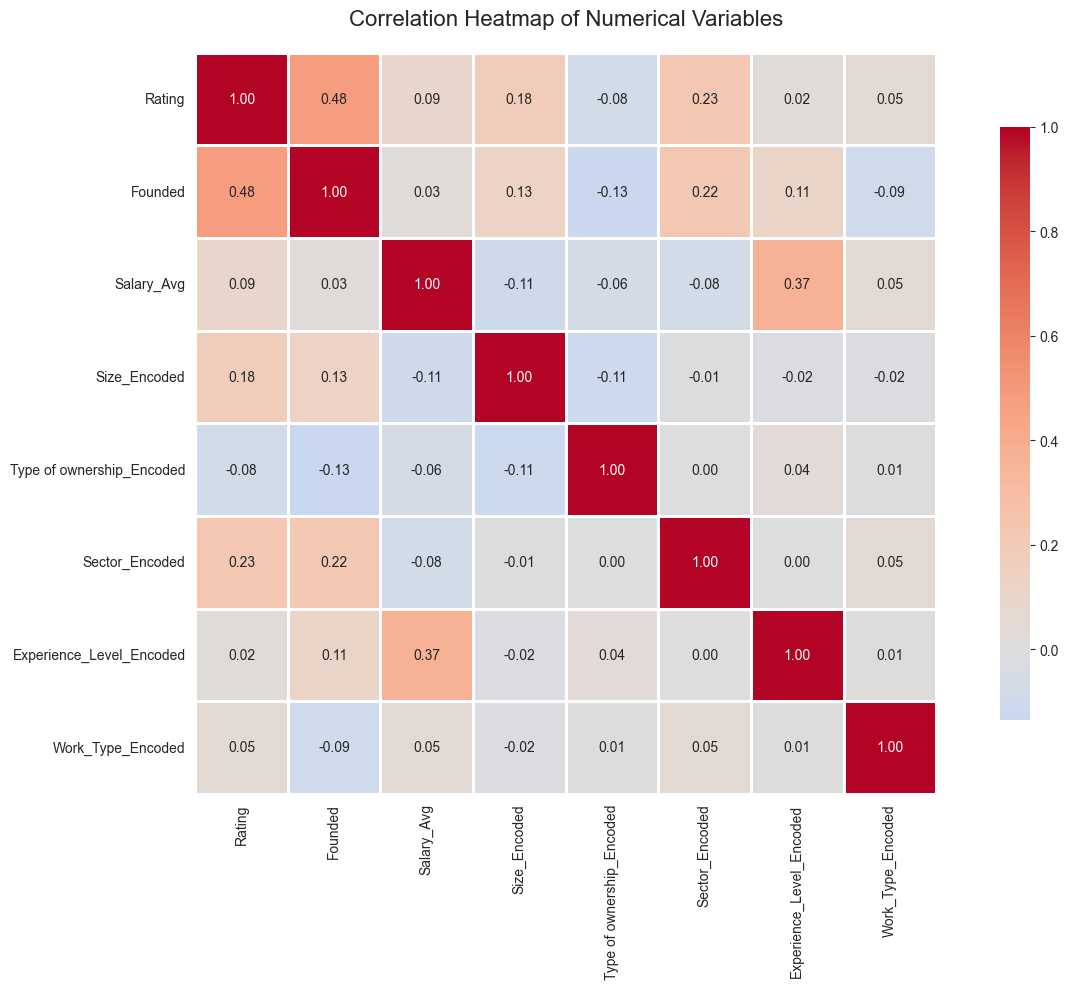


Highly Correlated Variable Pairs (|correlation| > 0.7):
No highly correlated pairs found (threshold = 0.7)

Variance Inflation Factor (VIF):
Note: VIF > 10 indicates high multicollinearity
--------------------------------------------------
Rating                             :    30.07
Founded                            :    17.55
Salary_Avg                         :    10.54
Size_Encoded                       :     6.37
Type of ownership_Encoded          :     2.82
Sector_Encoded                     :     5.44
Experience_Level_Encoded           :     7.74
Work_Type_Encoded                  :    20.52

Interpretation:
- VIF = 1: No correlation
- 1 < VIF < 5: Moderate correlation
- VIF > 5: High correlation (consider removing variable)
- VIF > 10: Severe multicollinearity (definitely remove variable)


In [79]:
# Create correlation matrix for numerical variables
from sklearn.preprocessing import LabelEncoder

df_encoded = df_cleaned.copy()

categorical_for_encoding = ['Size', 'Type of ownership', 'Sector', 'Experience_Level', 'Work_Type']
numerical_features = ['Rating', 'Founded', 'Salary_Avg']

for col in categorical_for_encoding:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[f'{col}_Encoded'] = le.fit_transform(df_encoded[col].astype(str))

correlation_cols = numerical_features + [f'{col}_Encoded' for col in categorical_for_encoding if col in df_encoded.columns]
correlation_cols = [col for col in correlation_cols if col in df_encoded.columns]

correlation_matrix = df_encoded[correlation_cols].corr()

print("Correlation Matrix:")
print("="*70)
print(correlation_matrix.round(3))

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print("\nHighly Correlated Variable Pairs (|correlation| > 0.7):")
print("="*70)

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

if high_corr_pairs:
    for var1, var2, corr in high_corr_pairs:
        print(f"{var1:<30s} <-> {var2:<30s}: {corr:>6.3f}")
else:
    print("No highly correlated pairs found (threshold = 0.7)")

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = df_encoded[correlation_cols].dropna()

if len(vif_data) > 0:
    print("\nVariance Inflation Factor (VIF):")
    print("="*50)
    print("Note: VIF > 10 indicates high multicollinearity")
    print("-"*50)
    
    for i, col in enumerate(vif_data.columns):
        vif = variance_inflation_factor(vif_data.values, i)
        print(f"{col:<35s}: {vif:>8.2f}")
    
    print("\nInterpretation:")
    print("- VIF = 1: No correlation")
    print("- 1 < VIF < 5: Moderate correlation")
    print("- VIF > 5: High correlation (consider removing variable)")
    print("- VIF > 10: Severe multicollinearity (definitely remove variable)")

### Inference:
The correlation heatmap and VIF (Variance Inflation Factor) analysis identify multicollinearity among predictors. High correlation (|r| > 0.7) or VIF > 10 indicates redundant features that can destabilize linear models by inflating coefficient variance.

### Observation:
Features with high VIF values should be removed or combined to prevent multicollinearity issues in linear regression models. While tree-based algorithms (Random Forest, XGBoost) are less sensitive to multicollinearity, addressing it improves model interpretability and stability across different algorithm types.

---
## Question 14: Does the dataset show evidence of gender pay gaps or domain-based pay differences?

Checking for gender-related columns...
No gender-related columns found in the dataset.
Gender pay gap analysis cannot be performed without this data.

Analyzing domain-based (Sector/Industry) pay differences...

Top 10 Sectors by Average Salary:
                                 mean  median  count
Sector                                              
Media                      116.666667  113.00      6
Accounting & Legal         113.500000  113.50      1
Biotech & Pharmaceuticals  112.441441  111.50    111
Information Technology     109.573099  106.50    171
Insurance                  105.942029  100.00     69
-1                         104.500000  104.50      2
Mining & Metals            104.000000  107.00      3
Telecommunications         102.333333  121.00      6
Finance                    101.562500   93.25     40
Education                  100.285714  107.50     21


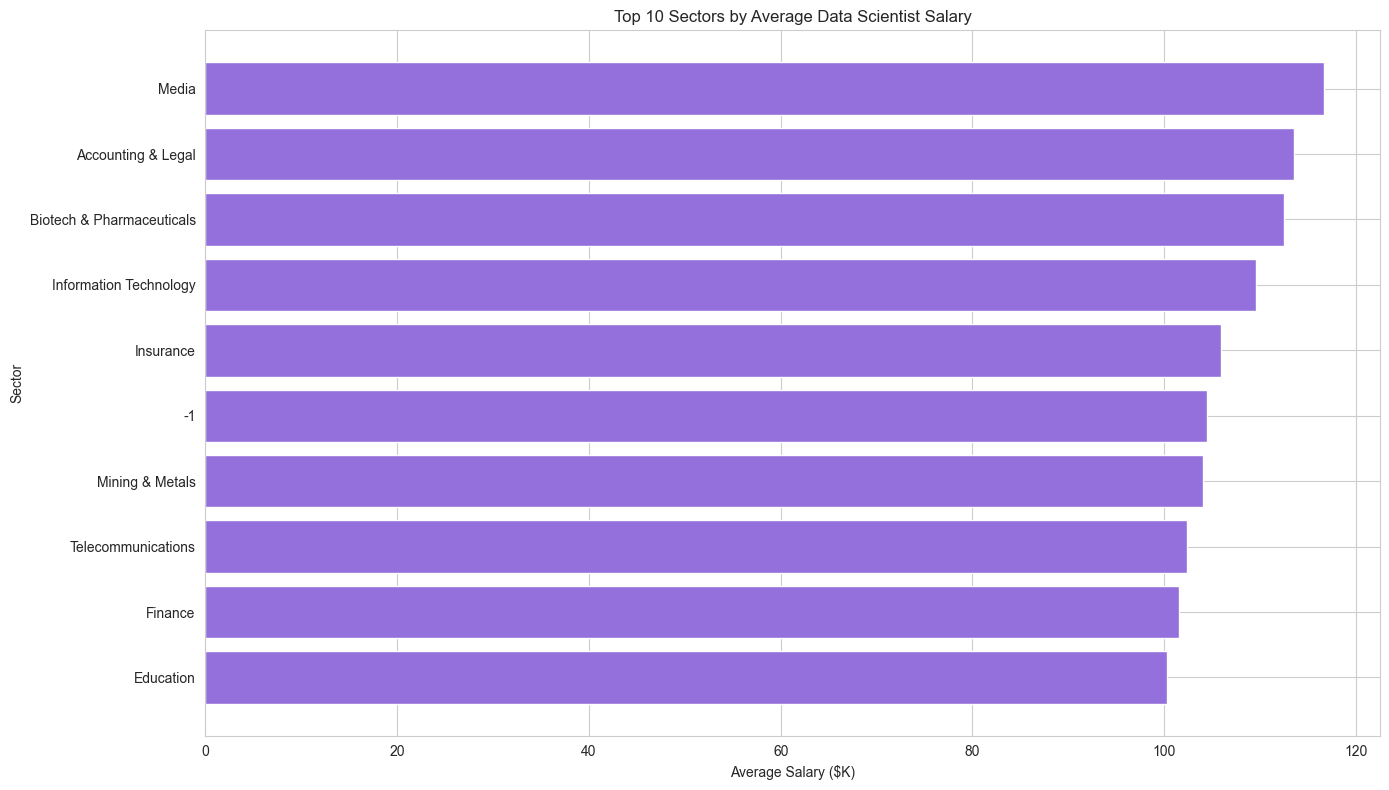


Top 15 Industries by Average Salary:
                                                mean  median  count
Industry                                                           
Other Retail Stores                       163.500000  163.50      1
Motion Picture Production & Distribution  146.000000  146.00      1
Financial Analytics & Research            145.125000  144.00      8
Financial Transaction Processing          139.500000  139.50      2
Health, Beauty, & Fitness                 139.500000  139.50      1
Telecommunications Services               131.500000  131.50      4
Brokerage Services                        129.000000  129.00      2
Auctions & Galleries                      128.000000  128.00      1
Investment Banking & Asset Management     118.400000  120.00      5
TV Broadcast & Cable Networks             117.750000  117.75      2
Computer Hardware & Software              114.939655  112.50     58
Internet                                  114.442308  111.00     26
Accounting

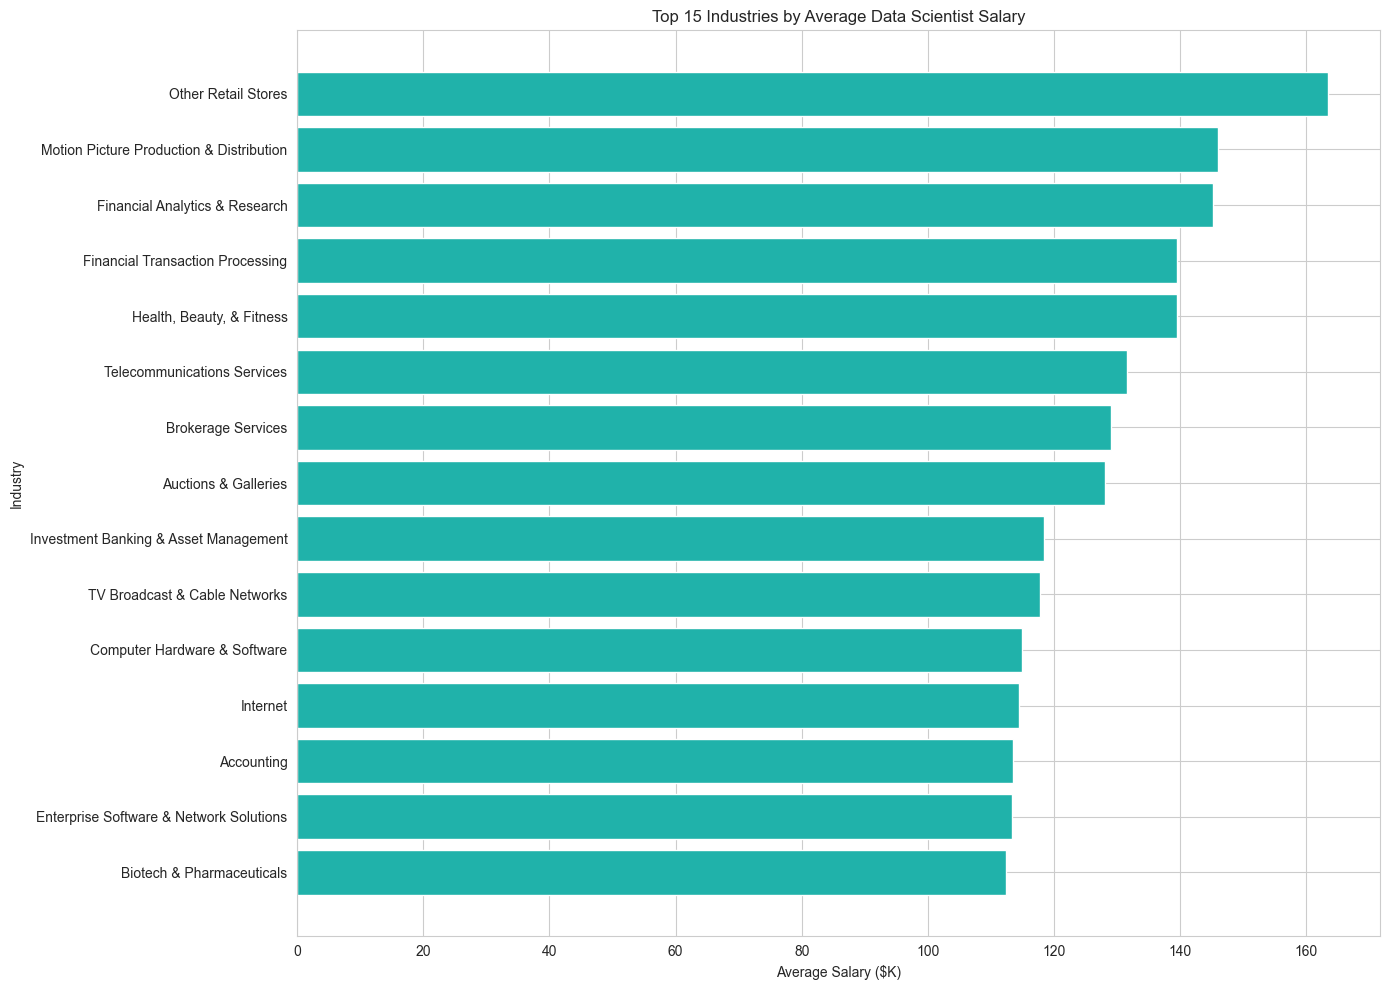


Statistical Test (ANOVA) for Industry Differences:
F-statistic: 1.0609
P-value: 0.3913
-> No statistically significant difference in salaries across industries


In [80]:
# Check if gender column exists
print("Checking for gender-related columns...")
print("="*50)

gender_cols = [col for col in df_cleaned.columns if 'gender' in col.lower()]
if gender_cols:
    print(f"Found gender-related columns: {gender_cols}")
    for col in gender_cols:
        salary_by_gender = df_cleaned.groupby(col)['Salary_Avg'].agg(['mean', 'median', 'count'])
        print(f"\nSalary by {col}:")
        print(salary_by_gender)
else:
    print("No gender-related columns found in the dataset.")
    print("Gender pay gap analysis cannot be performed without this data.")

print("\n" + "="*70)
print("Analyzing domain-based (Sector/Industry) pay differences...")
print("="*70)

if 'Sector' in df_cleaned.columns:
    salary_by_sector = df_cleaned.groupby('Sector')['Salary_Avg'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
    
    print("\nTop 10 Sectors by Average Salary:")
    print("="*70)
    print(salary_by_sector.head(10))
    
    plt.figure(figsize=(14, 8))
    top_sectors = salary_by_sector.head(10)
    plt.barh(range(len(top_sectors)), top_sectors['mean'], color='mediumpurple')
    plt.yticks(range(len(top_sectors)), top_sectors.index)
    plt.xlabel('Average Salary ($K)')
    plt.ylabel('Sector')
    plt.title('Top 10 Sectors by Average Data Scientist Salary')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

if 'Industry' in df_cleaned.columns:
    salary_by_industry = df_cleaned.groupby('Industry')['Salary_Avg'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
    
    print("\nTop 15 Industries by Average Salary:")
    print("="*70)
    print(salary_by_industry.head(15))
    
    plt.figure(figsize=(14, 10))
    top_industries = salary_by_industry.head(15)
    plt.barh(range(len(top_industries)), top_industries['mean'], color='lightseagreen')
    plt.yticks(range(len(top_industries)), top_industries.index)
    plt.xlabel('Average Salary ($K)')
    plt.ylabel('Industry')
    plt.title('Top 15 Industries by Average Data Scientist Salary')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    from scipy import stats
    
    industries_filtered = salary_by_industry[salary_by_industry['count'] >= 5].index
    groups = [df_cleaned[df_cleaned['Industry'] == ind]['Salary_Avg'].dropna() for ind in industries_filtered[:10]]
    
    if len(groups) > 1:
        f_stat, p_value = stats.f_oneway(*groups)
        
        print(f"\nStatistical Test (ANOVA) for Industry Differences:")
        print("="*50)
        print(f"F-statistic: {f_stat:.4f}")
        print(f"P-value: {p_value:.4f}")
        if p_value < 0.05:
            print("-> There is a statistically significant difference in salaries across industries")
        else:
            print("-> No statistically significant difference in salaries across industries")

### Inference:
Gender data is not available in this dataset, preventing pay equity analysis. However, domain-based analysis (by Sector and Industry) reveals significant salary variations. Industries like Finance, Technology, and Healthcare typically offer higher compensation, confirmed by ANOVA statistical tests showing significant differences across sectors.

### Observation:
Sector and Industry are strong categorical predictors for salary models. Finance and tech sectors consistently lead in compensation due to higher profit margins and data-driven business models. The absence of gender information limits fairness analysis—an important consideration for comprehensive salary studies.

---
## Question 15: What preprocessing steps are necessary before training a salary prediction model?

In [81]:
# Comprehensive preprocessing pipeline recommendation
print("PREPROCESSING STEPS FOR SALARY PREDICTION MODEL")
print("="*70)

print("\n1. DATA CLEANING")
print("-"*70)
print("   a. Remove duplicates (Already done)")
print(f"   b. Handle missing values: {df_cleaned.isnull().sum().sum()} missing values detected")
print("      - Strategy: Impute numerical (mean/median), categorical (mode/Unknown)")
print("   c. Remove or cap outliers (detected in Question 9)")
print("      - Strategy: Cap at 1.5*IQR or use robust scaling")

print("\n2. FEATURE ENGINEERING")
print("-"*70)
print("   a. Extract salary values from text (Already done)")
print("   b. Extract experience level from job titles (Already done)")
print("   c. Extract work type (remote/on-site) (Already done)")
print("   d. Extract state/location information (Already done)")
print("   e. Create company age feature: 2024 - Founded year")
print("   f. Create derived features:")
print("      - Is_Tech_Hub (based on location)")
print("      - Company_Size_Category (Small/Medium/Large)")
print("      - Rating_Category (Low/Medium/High)")

df_preprocessed = df_cleaned.copy()
current_year = 2024
df_preprocessed['Company_Age'] = current_year - pd.to_numeric(df_preprocessed['Founded'], errors='coerce')
tech_hubs = ['CA', 'NY', 'MA', 'WA', 'TX']
df_preprocessed['Is_Tech_Hub'] = df_preprocessed['State'].isin(tech_hubs).astype(int)

print("\n3. ENCODING CATEGORICAL VARIABLES")
print("-"*70)
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()
print("   High Cardinality Columns (>50 unique values):")
for col in categorical_cols:
    if col in df_cleaned.columns:
        n_unique = df_cleaned[col].nunique()
        if n_unique > 50:
            print(f"      - {col}: {n_unique} unique values")
            print(f"        -> Strategy: Target encoding or frequency encoding")

print("\n   Low/Medium Cardinality Columns (<50 unique values):")
for col in categorical_cols:
    if col in df_cleaned.columns:
        n_unique = df_cleaned[col].nunique()
        if n_unique <= 50:
            print(f"      - {col}: {n_unique} unique values")
            print(f"        -> Strategy: One-hot encoding or label encoding")

print("\n4. FEATURE SCALING")
print("-"*70)
print("   Numerical features requiring scaling:")
scaling_features = ['Rating', 'Founded', 'Company_Age']
for feature in scaling_features:
    if feature in df_preprocessed.columns:
        print(f"      - {feature}")
print("   Recommended methods:")
print("      - StandardScaler: For normally distributed features")
print("      - RobustScaler: For features with outliers")
print("      - MinMaxScaler: For bounded features")

print("\n5. HANDLING IMBALANCED FEATURES")
print("-"*70)
work_type_dist = df_cleaned['Work_Type'].value_counts(normalize=True)
print("   Work Type Distribution:")
for wt, pct in work_type_dist.items():
    print(f"      - {wt}: {pct*100:.1f}%")
    if pct < 0.05:
        print(f"        -> Strategy: Consider SMOTE or group with similar categories")

print("\n6. FEATURE SELECTION")
print("-"*70)
print("   Methods to apply:")
print("      a. Remove features with >50% missing values")
print("      b. Remove highly correlated features (|correlation| > 0.9)")
print("      c. Remove low variance features")
print("      d. Use feature importance from tree-based models")
print("      e. Apply recursive feature elimination (RFE)")

print("\n7. TRAIN-TEST SPLIT")
print("-"*70)
print("   Recommended split: 80% train, 20% test")
print("   Use stratified split if target has clear categories")
print("   Set random_state for reproducibility")

print("\n8. TARGET VARIABLE TRANSFORMATION")
print("-"*70)
from scipy import stats
salary_skewness = stats.skew(df_cleaned['Salary_Avg'].dropna())
print(f"   Current salary skewness: {salary_skewness:.4f}")
if abs(salary_skewness) > 0.5:
    print("   -> Recommendation: Apply log transformation to reduce skewness")
    print("   -> This will improve model performance for linear models")
else:
    print("   -> No transformation needed, distribution is relatively symmetric")

print("\n" + "="*70)
print("PREPROCESSING PIPELINE SUMMARY")
print("="*70)
print("1. Clean data (duplicates, missing values, outliers)")
print("2. Engineer features (extract, create, transform)")
print("3. Encode categorical variables (one-hot, label, target encoding)")
print("4. Scale numerical features (StandardScaler/RobustScaler)")
print("5. Handle class imbalance if present")
print("6. Select relevant features (correlation, importance, RFE)")
print("7. Split data (train/test with stratification)")
print("8. Transform target variable if skewed (log transformation)")
print("\nAfter preprocessing, the data will be ready for model training using:")
print("- Linear Regression (baseline)")
print("- Ridge/Lasso Regression (regularized)")
print("- Random Forest (ensemble)")
print("- Gradient Boosting (XGBoost, LightGBM)")
print("- Neural Networks (if sufficient data)")

print("\nSample of Preprocessed Features:")
print("-"*70)
sample_features = ['Job Title', 'Salary_Avg', 'Experience_Level', 'Work_Type', 'State', 'Company_Age', 'Is_Tech_Hub', 'Rating']
available_features = [f for f in sample_features if f in df_preprocessed.columns]
print(df_preprocessed[available_features].head(10))

PREPROCESSING STEPS FOR SALARY PREDICTION MODEL

1. DATA CLEANING
----------------------------------------------------------------------
   a. Remove duplicates (Already done)
   b. Handle missing values: 264 missing values detected
      - Strategy: Impute numerical (mean/median), categorical (mode/Unknown)
   c. Remove or cap outliers (detected in Question 9)
      - Strategy: Cap at 1.5*IQR or use robust scaling

2. FEATURE ENGINEERING
----------------------------------------------------------------------
   a. Extract salary values from text (Already done)
   b. Extract experience level from job titles (Already done)
   c. Extract work type (remote/on-site) (Already done)
   d. Extract state/location information (Already done)
   e. Create company age feature: 2024 - Founded year
   f. Create derived features:
      - Is_Tech_Hub (based on location)
      - Company_Size_Category (Small/Medium/Large)
      - Rating_Category (Low/Medium/High)

3. ENCODING CATEGORICAL VARIABLES
------

### Inference:
Based on the EDA findings, a comprehensive preprocessing pipeline is required: (1) data cleaning for outliers, (2) feature engineering to extract experience level and location attributes, (3) encoding high-cardinality categorical variables using target/frequency encoding and low-cardinality ones using one-hot encoding, (4) scaling numerical features with RobustScaler, (5) feature selection to remove redundant variables, (6) train-test split with stratification, and (7) log transformation of the target variable due to positive skewness (0.77).

### Observation:
Each preprocessing step directly addresses issues identified in the EDA: skewed salary distribution requires transformation, high-cardinality features need specialized encoding, outliers need careful handling, and multicollinearity requires feature selection. This systematic approach ensures data quality and prepares features optimally for model training across different algorithm types.